## Домашнее задание 1

Основная цель домашнего задания:
- Отработать основные методы визуализации данных, рассмотренные в первом модуле.
- Научиться проводить качественный разведочный анализ данных (EDA), используя методы визуализации. Описать полученные результаты.
- Используя два метода, которые мы рассмотрели в первом модуле, закрепить принципы идентификации выбросов в данных.
- Разобрать способы использования визуализации при решении задачи регрессии.

**ВАЖНО.** Каждый график должен быть полностью оформлен (иметь заголовок, названия осей и т. д.)

## Задание 1. Знакомство с данными и EDA (4 балла)

### Описание задачи

В этом домашнем задании проводится разведочный анализ данных (Exploratory Data Analysis, EDA) на основе базы экологических характеристик строительных материалов **ÖKOBAUDAT**. Данный датасет содержит информацию из экологических деклараций продукции (Environmental Product Declarations, EPD), включая показатели воздействия строительных материалов на окружающую среду, такие как потенциал глобального потепления (GWP), потребление первичной энергии и другие категории жизненного цикла.

В отличие от анализа рынка недвижимости, целью данного исследования является изучение взаимосвязей между характеристиками строительных материалов и их экологическим воздействием. В рамках разведочного анализа планируется исследовать распределение ключевых показателей, выявить возможные выбросы (outliers), проанализировать корреляции между признаками и определить, какие характеристики материалов могут быть полезны для дальнейшего моделирования и прогнозирования экологических показателей.

### Почему используется датасет ÖKOBAUDAT

База **ÖKOBAUDAT** является официальной немецкой национальной базой данных экологических показателей строительных материалов, поддерживаемой Federal Ministry for Housing, Urban Development and Building. Она служит основным источником экологических данных для оценки жизненного цикла зданий и используется в различных инструментах экологической оценки.

Этот датасет играет ключевую роль для немецкого строительного сектора по нескольким причинам:

1. **Стандартизированные данные LCA**
   ÖKOBAUDAT содержит данные, соответствующие европейским стандартам экологической оценки строительных продуктов (например, EN 15804). Это позволяет проводить сопоставимые оценки воздействия различных материалов.

2. **Поддержка устойчивого проектирования зданий**
   Архитекторы, инженеры и консультанты по устойчивому строительству используют данные ÖKOBAUDAT для расчета экологического следа зданий на этапе проектирования.

3. **Интеграция с BIM и цифровыми инструментами**
   Данные из ÖKOBAUDAT активно применяются в цифровых инструментах моделирования зданий и расчетах жизненного цикла, что делает их важным компонентом современных BIM-процессов.

4. **Соответствие требованиям немецких стандартов устойчивого строительства**
   База используется при проведении экологической оценки зданий в рамках систем сертификации, таких как DGNB.

Таким образом, анализ данных ÖKOBAUDAT позволяет лучше понять экологические характеристики строительных материалов и является важным шагом к разработке инструментов для более устойчивого и экологически эффективного проектирования зданий.


In [115]:
%pip install pycountry
%pip install folium
%pip install catboost

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [136]:
# Импортируем библиотеки и данные
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from catboost import CatBoostRegressor

In [117]:
CSV_PATH = Path("data/OBD_2024_I_2026-02-19T12_56_13.csv")

raw = pd.read_csv(CSV_PATH, sep=";", encoding="cp1252", low_memory=False)
df = raw[raw["Typ"].ne("template dataset")].copy()
df = df.drop(columns=["Unnamed: 99"], errors="ignore")

indicator_cols = [
    c for c in [
        "PERE", "PERM", "PERT", "PENRE", "PENRM", "PENRT",
        "AP (A2)", "GWPtotal (A2)", "GWPbiogenic (A2)", "GWPfossil (A2)", "GWPluluc (A2)",
        "ETPfw (A2)", "PM (A2)", "EPmarine (A2)", "EPfreshwater (A2)", "EPterrestrial (A2)",
        "HTPc (A2)", "HTPnc (A2)", "IRP (A2)", "SOP (A2)", "ODP (A2)", "POCP (A2)",
        "ADPF (A2)", "ADPE (A2)", "WDP (A2)"
    ] if c in df.columns
]
physical_cols = [
    c for c in [
        "Flaechengewicht (kg/m2)", "Rohdichte (kg/m3)",
        "Schichtdicke (m)", "Laengengewicht (kg/m)",
        "Stueckgewicht (kg)", "Umrechungsfaktor auf 1kg",
        "biogener Kohlenstoffgehalt in kg", "biogener Kohlenstoffgehalt (Verpackung) in kg"
    ] if c in df.columns
]
for c in indicator_cols + physical_cols:
    df[c] = pd.to_numeric(df[c].astype(str).str.replace(",", ".", regex=False), errors="coerce")


meta_cols = [
    c for c in [
        "Name (en)", "Name (de)", "Kategorie (en)", "Kategorie (original)",
        "Konformitaet", "Laenderkennung", "Typ", "Declaration owner",
        "Bezugsgroesse", "Bezugseinheit", "Referenzjahr", "Gueltig bis", "URL"
    ] if c in df.columns
]
df_meta = df.groupby("UUID", as_index=False).first()[["UUID"] + meta_cols + physical_cols]
df_a1a3 = df[df["Modul"].eq("A1-A3")].groupby("UUID", as_index=False).first()[["UUID"] + indicator_cols]

df_clean = df_meta.merge(df_a1a3, on="UUID", how="left")
gwp_col = "GWPtotal (A2)" if "GWPtotal (A2)" in df_clean.columns else "GWP"
df_clean = df_clean[df_clean[gwp_col].notna()].reset_index(drop=True)

print(df_clean.shape)
df_clean.head()

(2491, 47)


,UUID,Name (en),Name (de),Kategorie (en),Kategorie (original),Konformitaet,Laenderkennung,Typ,Declaration owner,Bezugsgroesse,...,EPterrestrial (A2),HTPc (A2),HTPnc (A2),IRP (A2),SOP (A2),ODP (A2),POCP (A2),ADPF (A2),ADPE (A2),WDP (A2)
0,00223887-863d-4f72-a641-21fcaf64629e,"Masterdenz 100 7.3N, Mix Design ID: RMBLOCK02 ...","Masterdenz 100 7.3n, Mix Design ID: Rmblock02 ...","'Mineral building products' / 'Bricks, blocks ...",'Mineralische Baustoffe' / 'Steine und Element...,'EN 15804+A2' / 'ISO 14025',GB,specific dataset,Holcim UK Ltd,1,...,0.131735,1.800000e-08,4.162000e-07,0.641897,68.082827,1.759000e-07,0.034248,59.876457,1.214440e-05,0.892143
1,00485255-d8a7-4e6d-b2ab-fba929e3cc4a,Cement,Zement,'Mineral building products' / 'Binder' / 'Cement','Mineralische Baustoffe' / 'Bindemittel' / 'Ze...,'DIN EN 15804+A2' / 'ISO 14025',AT,average dataset,Vereinigung der Österreichischen Zementindustr...,1000,...,3.390000,NaN,NaN,11.400000,NaN,5.780000e-06,0.782000,1620.000000,5.470000e-05,41.000000
2,004f3f4e-5bb8-4d9e-a104-6999a9e8ad5b,Gypsum lime plaster,Gips Kalk Putz,'Mineral building products' / 'Mortar and Conc...,'Mineralische Baustoffe' / 'Mörtel und Beton' ...,'EN 15804+A2 (EF 3.1)',DE,generic dataset,Sphera Solutions GmbH,1,...,0.814023,NaN,NaN,NaN,NaN,9.758386e-10,0.190559,1814.159838,9.022259e-06,7.721739
3,006c17a5-bfbd-4786-8c96-7546e5317f9c,"SAGLAN glass wool, bonded with bio-based adhes...","SAGLAN Glaswolle, mit bio-basiertem Bindemitte...",'Insulation materials' / 'Mineral wool' / 'Gla...,'Dämmstoffe' / 'Mineralwolle' / 'Glaswolle','DIN EN 15804+A2' / 'ISO 14025',CH,specific dataset,Sager AG,1,...,0.037044,2.505862e-10,6.707243e-09,0.403321,1.360446,1.342780e-07,0.003070,27.091068,1.836399e-06,654.901635
4,00ca5ee8-45ff-4b48-99ce-00b979de349e,CROSSIGN 160 SP2-E002-D,CROSSIGN 160 SP2-E002-D,'Building service engineering' / 'Electrical' ...,'Gebäudetechnik' / 'Elektro' / 'Beleuchtung','EN 15804+A2',EU,average dataset,Zumtobel Lighting GmbH,1,...,0.008725,NaN,NaN,NaN,NaN,1.148280e-11,0.002599,33.977860,3.376468e-07,0.096645


In [118]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2491 entries, 0 to 2490
Data columns (total 47 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   UUID                                           2491 non-null   object 
 1   Name (en)                                      2490 non-null   object 
 2   Name (de)                                      2331 non-null   object 
 3   Kategorie (en)                                 2491 non-null   object 
 4   Kategorie (original)                           2491 non-null   object 
 5   Konformitaet                                   2491 non-null   object 
 6   Laenderkennung                                 2491 non-null   object 
 7   Typ                                            2491 non-null   object 
 8   Declaration owner                              2491 non-null   object 
 9   Bezugsgroesse                                  2488 

In [119]:
# Выделим несколько уровней категорий

if "Kategorie (en)" not in df_clean.columns:
    raise KeyError("Column 'Kategorie (en)' not found")

parts = (
    df_clean["Kategorie (en)"]
    .fillna("")
    .astype(str)
    .str.split("/", n=2, expand=True)
)

df_clean["Top_category"] = parts[0].str.strip(" '\"").replace("", "Unknown")
df_clean["Sub_category"] = (
    parts[1] if 1 in parts.columns else "Unknown"
)
df_clean["Sub_category"] = df_clean["Sub_category"].astype(str).str.strip(" '\"").replace("", "Unknown")

category_map = (
    df_clean[["Top_category", "Sub_category"]]
    .drop_duplicates()
    .sort_values(["Top_category", "Sub_category"])
    .reset_index(drop=True)
)

print(f"Top categories: {df_clean['Top_category'].nunique()}")
print(f"Top+Sub pairs: {len(category_map)}")
display(category_map.head(20))

df_clean[["UUID", "Kategorie (en)", "Top_category", "Sub_category"]].head()

Top categories: 10
Top+Sub pairs: 75


,Top_category,Sub_category
0,Building service engineering,Air conditioning and ventilation
1,Building service engineering,Conveyance
2,Building service engineering,Electrical
3,Building service engineering,Fire protection
4,Building service engineering,Heating
5,Building service engineering,Sanitary
6,Building service engineering,Use
7,Components for windows and curtain walls,"Accessories for windows, walling and doors"
8,Components for windows and curtain walls,Daylight systems and smoke
9,Components for windows and curtain walls,Doors


,UUID,Kategorie (en),Top_category,Sub_category
0,00223887-863d-4f72-a641-21fcaf64629e,"'Mineral building products' / 'Bricks, blocks ...",Mineral building products,"Bricks, blocks and elements"
1,00485255-d8a7-4e6d-b2ab-fba929e3cc4a,'Mineral building products' / 'Binder' / 'Cement',Mineral building products,Binder
2,004f3f4e-5bb8-4d9e-a104-6999a9e8ad5b,'Mineral building products' / 'Mortar and Conc...,Mineral building products,Mortar and Concrete
3,006c17a5-bfbd-4786-8c96-7546e5317f9c,'Insulation materials' / 'Mineral wool' / 'Gla...,Insulation materials,Mineral wool
4,00ca5ee8-45ff-4b48-99ce-00b979de349e,'Building service engineering' / 'Electrical' ...,Building service engineering,Electrical


**Задание 1.1**

Создайте 6 визуализаций разных видов. Можно использовать графики из галерей [Matplotlib](https://matplotlib.org/stable/plot_types/index.html) или [Seaborn](https://seaborn.pydata.org/examples/index.html). Полученные графики отобразите и сохраните в отдельные переменные.

Каждый график должен иметь все стандартные аттрибуты: подписи осей, название и другие необходимые детали.

**NB** Визуализация должна иметь смысл и нести новую информацию.

c:\Users\olgap\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


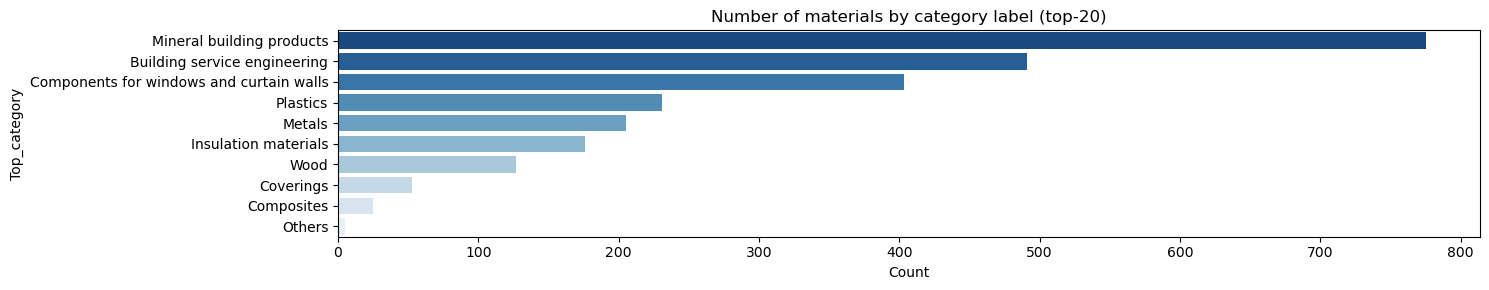

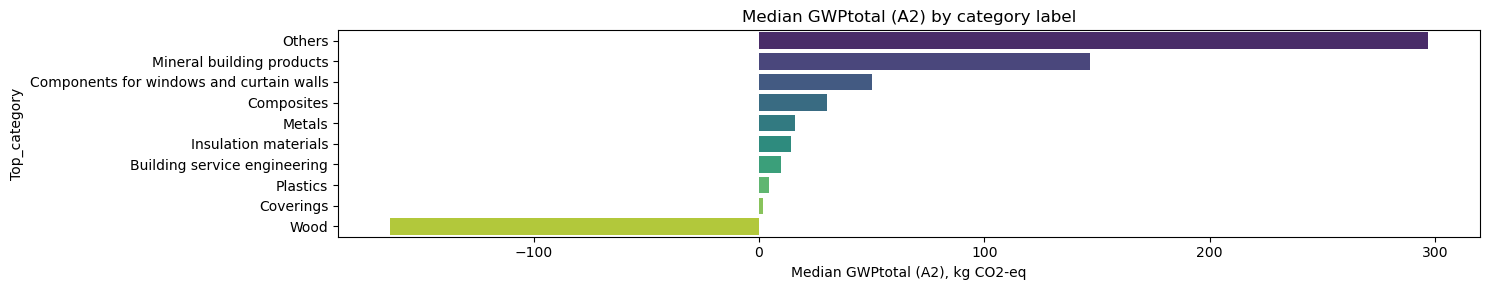

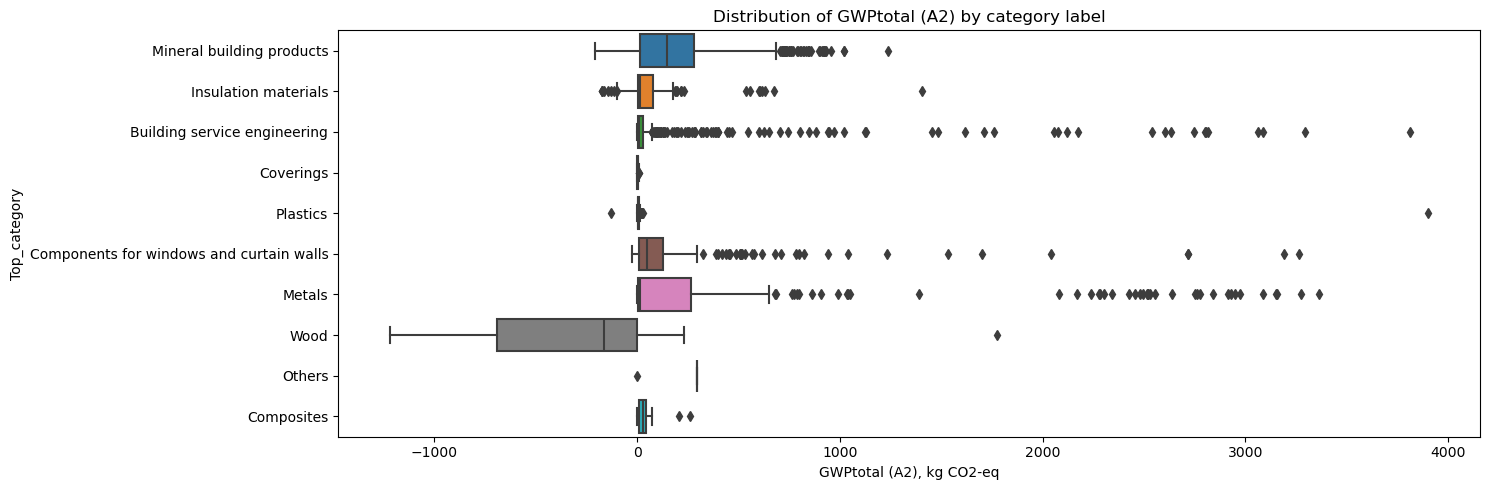

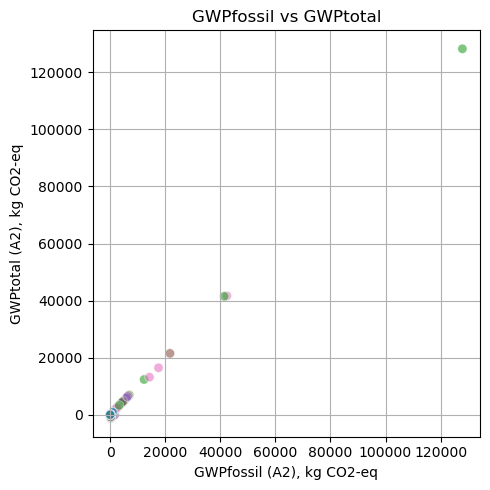

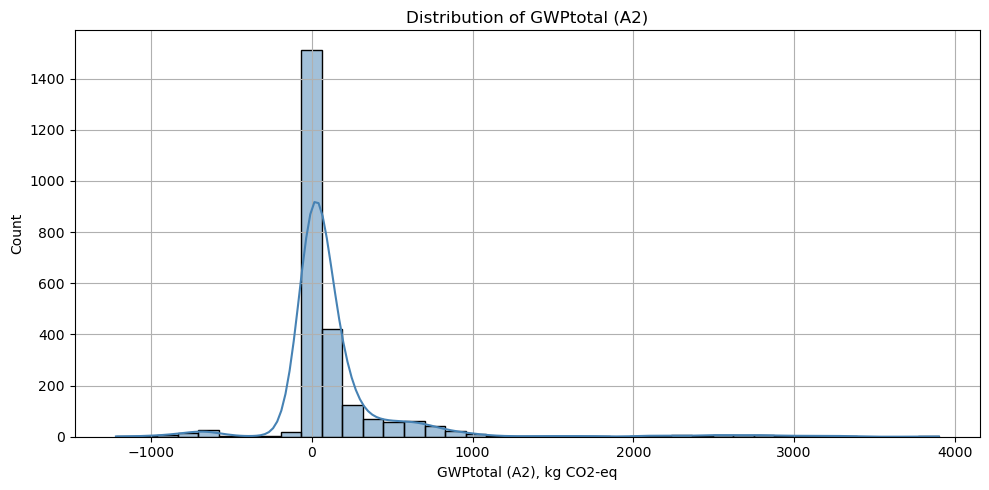

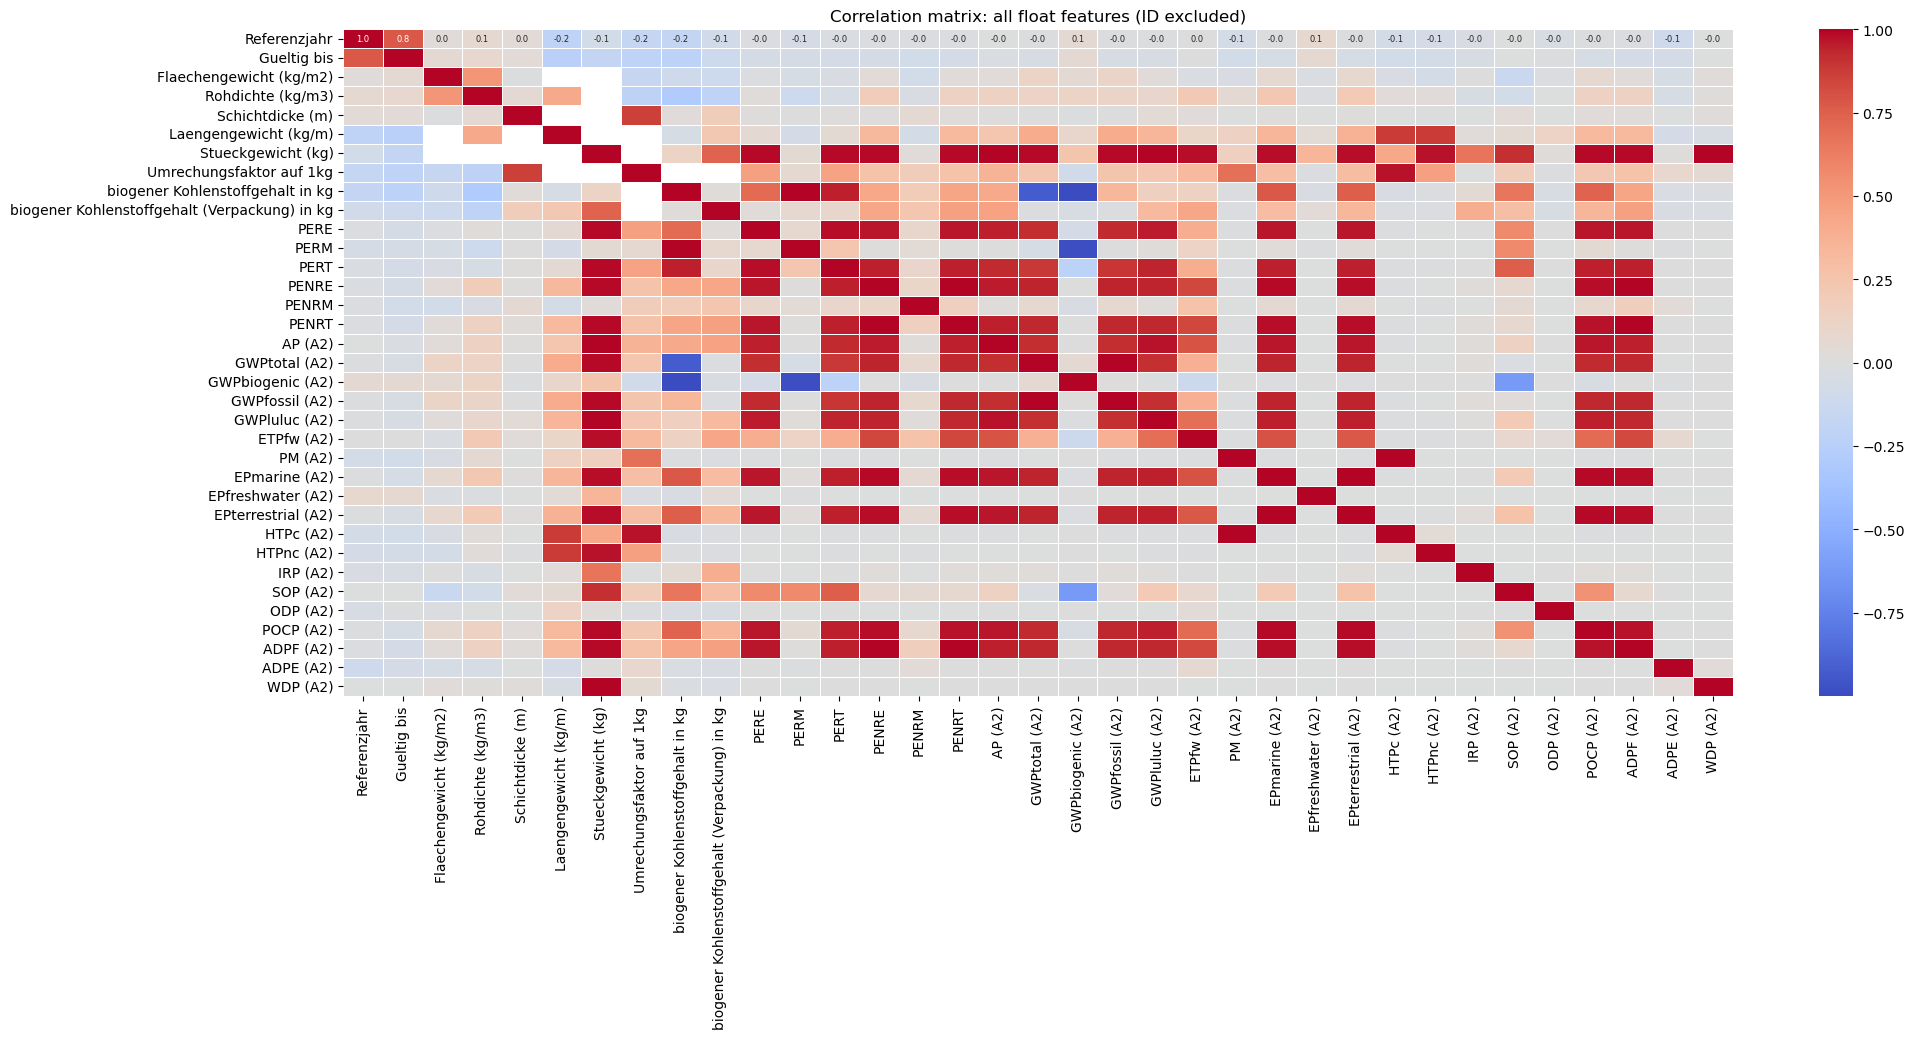

In [120]:
if "Top_category" not in df_clean.columns:
    raise KeyError("Run the encoding cell first to create 'Top_category'.")

main_cols = [
    "Top_category",
    "GWPtotal (A2)",
    "GWPbiogenic (A2)",
    "GWPfossil (A2)",
    "GWPluluc (A2)"
]
extra_candidates = ["AP (A2)", "ODP (A2)", "PENRT", "PERT", "Rohdichte (kg/m3)"]
extra_cols = [c for c in extra_candidates if c in df_clean.columns]

work_cols = [c for c in main_cols + extra_cols if c in df_clean.columns]
plot_df = df_clean[work_cols].copy()
plot_df = plot_df[plot_df["Top_category"].notna()].copy()

# Ограничим топ категорий
cat_order = plot_df["Top_category"].value_counts().head(20).index
plot_top = plot_df[plot_df["Top_category"].isin(cat_order)].copy()

# 1) Кол-во материалов по категории
fig_1, ax_1 = plt.subplots(figsize=(15, 3))
sns.countplot(data=plot_top, y="Top_category", order=cat_order, ax=ax_1, palette="Blues_r")
ax_1.set_title("Number of materials by category label (top-20)")
ax_1.set_xlabel("Count")
ax_1.set_ylabel("Top_category")
plt.tight_layout()

# 2) median GWPtotal по категории 
fig_2, ax_2 = plt.subplots(figsize=(15, 3))
med_gwp = plot_top.groupby("Top_category")["GWPtotal (A2)"].median().sort_values(ascending=False)
sns.barplot(y=med_gwp.index, x=med_gwp.values, ax=ax_2, palette="viridis", orient="h")
ax_2.set_title("Median GWPtotal (A2) by category label")
ax_2.set_xlabel("Median GWPtotal (A2), kg CO2-eq")
ax_2.set_ylabel("Top_category")
plt.tight_layout()

# 3) распределение GWPtotal по категории
fig_3, ax_3 = plt.subplots(figsize=(15, 5))
gwp_q99 = plot_top["GWPtotal (A2)"].quantile(0.99)
box_df = plot_top[plot_top["GWPtotal (A2)"] <= gwp_q99]
sns.boxplot(data=box_df, y="Top_category", x="GWPtotal (A2)", ax=ax_3, orient="h")
ax_3.set_title("Distribution of GWPtotal (A2) by category label")
ax_3.set_xlabel("GWPtotal (A2), kg CO2-eq")
ax_3.set_ylabel("Top_category")
plt.tight_layout()

# 4) fossil vs total GWP
fig_4, ax_4 = plt.subplots(figsize=(5, 5))
scatter_df = plot_top.dropna(subset=["GWPfossil (A2)", "GWPtotal (A2)"])
sns.scatterplot(
    data=scatter_df,
    x="GWPfossil (A2)",
    y="GWPtotal (A2)",
    hue="Top_category",
    alpha=0.6,
    s=45,
    ax=ax_4,
    legend=False,
)
ax_4.set_title("GWPfossil vs GWPtotal")
ax_4.set_xlabel("GWPfossil (A2), kg CO2-eq")
ax_4.set_ylabel("GWPtotal (A2), kg CO2-eq")
ax_4.grid(True)
plt.tight_layout()

# 5) распределение GWPtotal
fig_5, ax_5 = plt.subplots(figsize=(10, 5))
hist_df = plot_df[plot_df["GWPtotal (A2)"] <= plot_df["GWPtotal (A2)"].quantile(0.99)]
sns.histplot(hist_df["GWPtotal (A2)"], bins=40, kde=True, color="steelblue", ax=ax_5)
ax_5.set_title("Distribution of GWPtotal (A2)")
ax_5.set_xlabel("GWPtotal (A2), kg CO2-eq")
ax_5.set_ylabel("Count")
ax_5.grid(True)
plt.tight_layout()

# 6) Кореляция числовых колонок
float_cols = df_clean.select_dtypes(include=["float", "float32", "float64"]).columns.tolist()
exclude_id_cols = [c for c in float_cols if (c.lower() == "id" or "id" in c.lower())]
corr_cols = [c for c in float_cols if c not in exclude_id_cols]

if len(corr_cols) < 2:
    raise ValueError("Not enough float columns to compute correlation matrix.")

corr = df_clean[corr_cols].corr(numeric_only=True)
size = max(10, min(24, int(len(corr_cols) * 0.6)))
fig_6, ax_6 = plt.subplots(figsize=(size, size/2))
sns.heatmap(
    corr,
    annot=True,          # показать числа
    fmt=".1f",           # 2 знака после запятой
    cmap="coolwarm",
    center=0,
    ax=ax_6,
    annot_kws={"size": 6},  # размер шрифта чисел
    linewidths=0.5,
    linecolor="white"
)
ax_6.set_title("Correlation matrix: all float features (ID excluded)")
plt.tight_layout()

**Задание 1.2**

В рамках модуля мы научились использовать функцию [plt.subplots](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.subplots.html) для создания «полотна» с целью отображения нескольких графиков на одном поле.
Создайте полотно размером 3x2 (три строки и два столбца). На этом полотне изобразите все графики, которые ранее были созданы в задании 1.1.

c:\Users\olgap\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


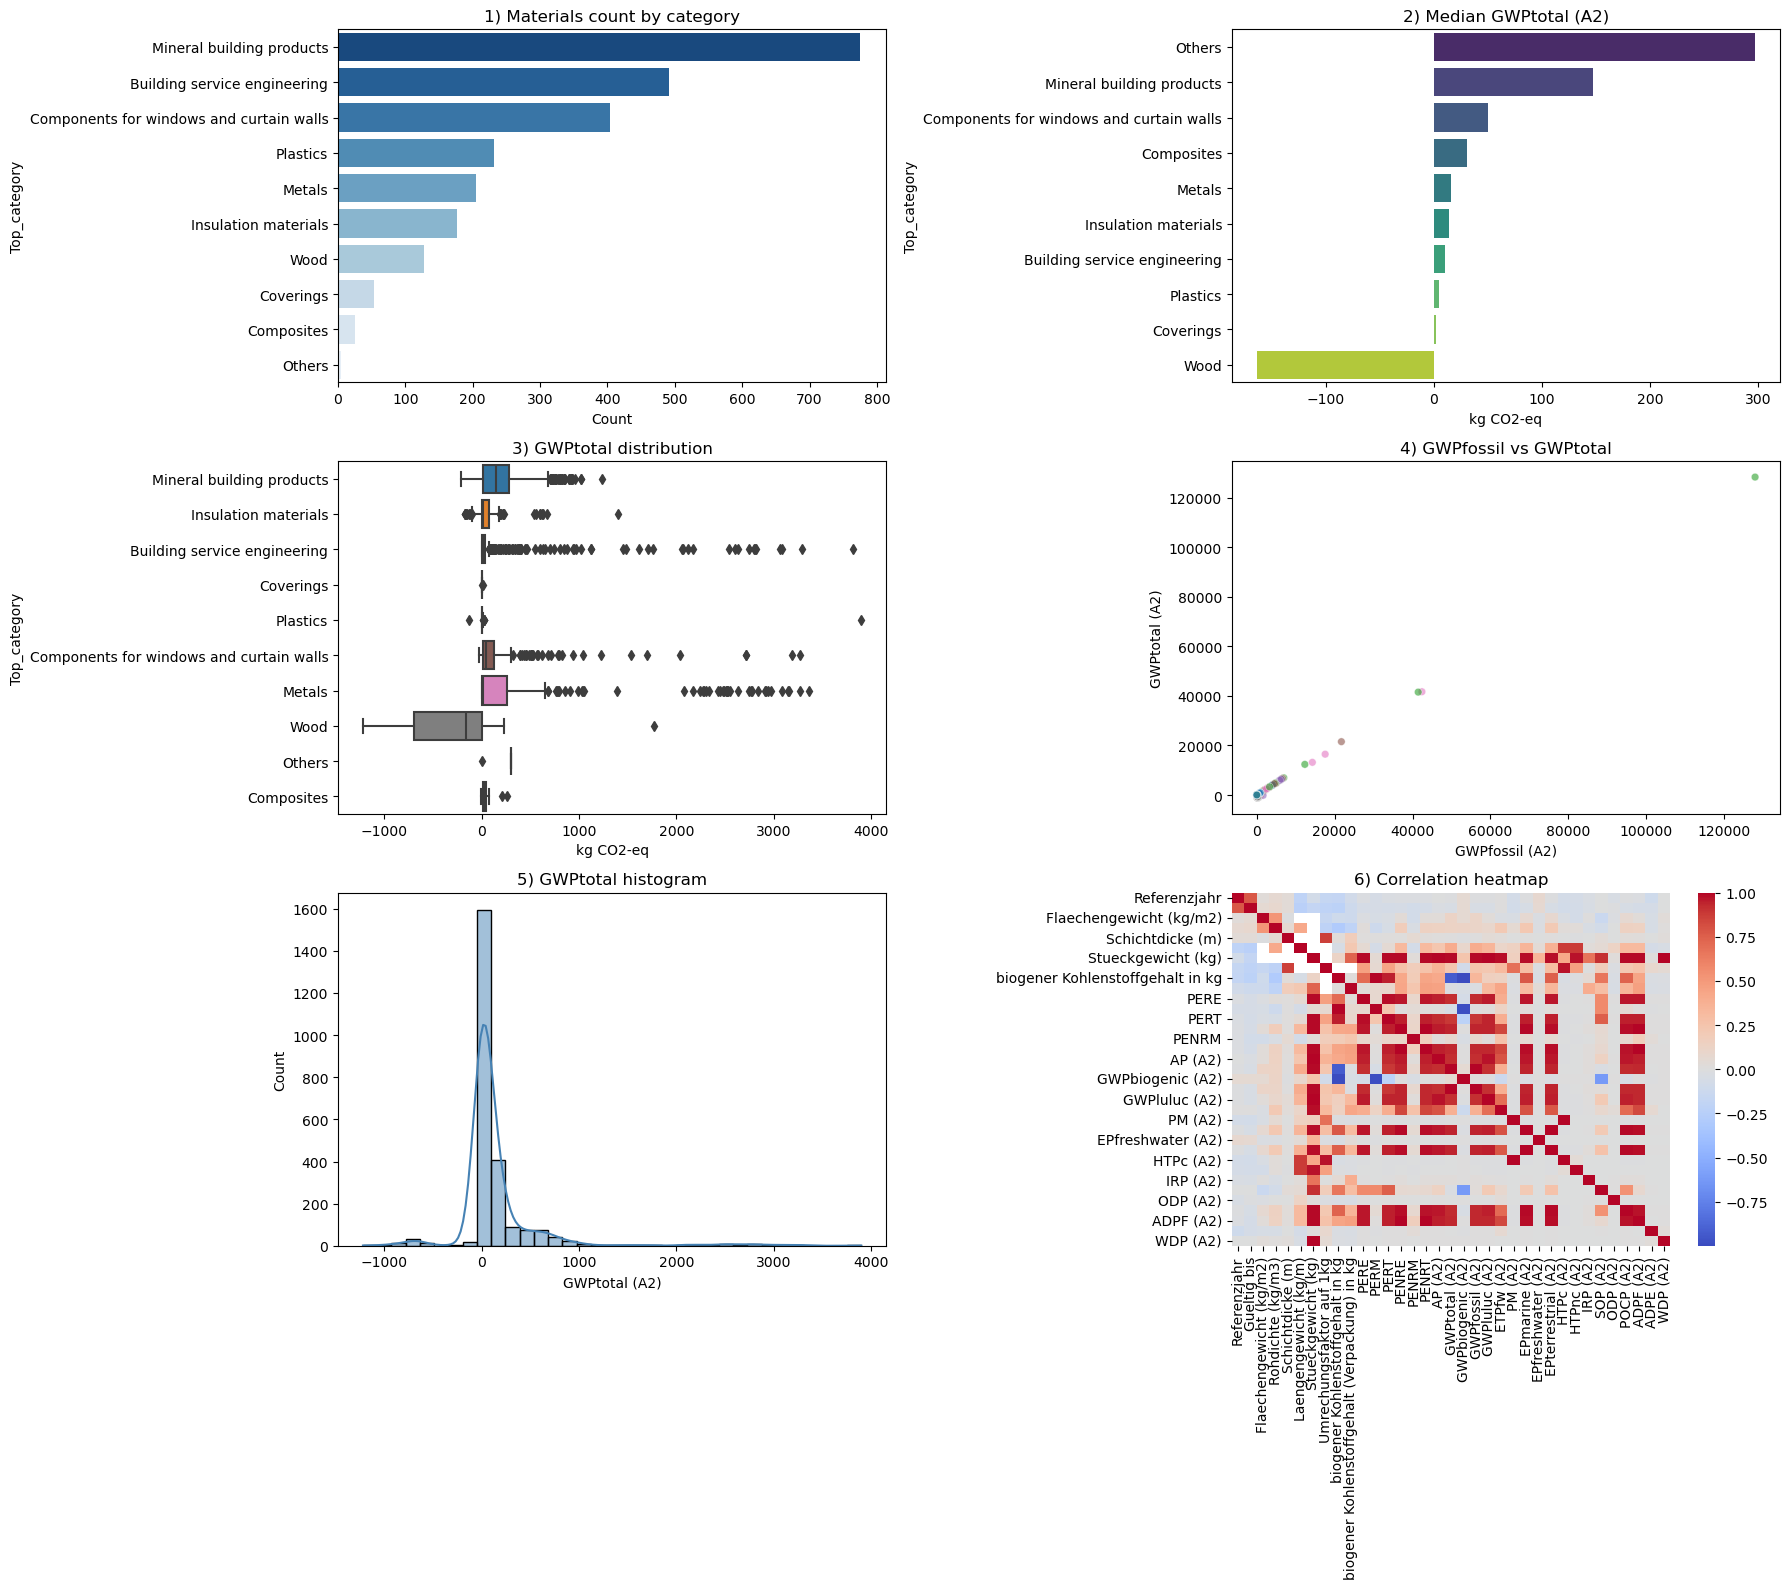

In [121]:
fig, axes = plt.subplots(3, 2, figsize=(18, 16))
axs = axes.ravel()

cat_col = "Top_category" if "Top_category" in plot_top.columns else "Kategorie (num)"
cat_order = plot_top[cat_col].value_counts().head(20).index
plot_top_local = plot_top[plot_top[cat_col].isin(cat_order)].copy()

sns.countplot(data=plot_top_local, y=cat_col, order=cat_order, ax=axs[0], palette="Blues_r")
axs[0].set_title("1) Materials count by category")
axs[0].set_xlabel("Count")
axs[0].set_ylabel(cat_col)

med_gwp = plot_top_local.groupby(cat_col)["GWPtotal (A2)"].median().sort_values(ascending=False)
sns.barplot(y=med_gwp.index, x=med_gwp.values, ax=axs[1], palette="viridis", orient="h")
axs[1].set_title("2) Median GWPtotal (A2)")
axs[1].set_xlabel("kg CO2-eq")
axs[1].set_ylabel(cat_col)

gwp_q99 = plot_top_local["GWPtotal (A2)"].quantile(0.99)
box_df = plot_top_local[plot_top_local["GWPtotal (A2)"] <= gwp_q99]
sns.boxplot(data=box_df, y=cat_col, x="GWPtotal (A2)", ax=axs[2], orient="h")
axs[2].set_title("3) GWPtotal distribution")
axs[2].set_xlabel("kg CO2-eq")
axs[2].set_ylabel(cat_col)

scatter_df = plot_top_local.dropna(subset=["GWPfossil (A2)", "GWPtotal (A2)"])
sns.scatterplot(
    data=scatter_df,
    x="GWPfossil (A2)",
    y="GWPtotal (A2)",
    hue=cat_col,
    alpha=0.6,
    s=30,
    ax=axs[3],
    legend=False,
)
axs[3].set_title("4) GWPfossil vs GWPtotal")
axs[3].set_xlabel("GWPfossil (A2)")
axs[3].set_ylabel("GWPtotal (A2)")

hist_df = plot_top_local[plot_top_local["GWPtotal (A2)"] <= plot_top_local["GWPtotal (A2)"].quantile(0.99)]
sns.histplot(hist_df["GWPtotal (A2)"], bins=35, kde=True, color="steelblue", ax=axs[4])
axs[4].set_title("5) GWPtotal histogram")
axs[4].set_xlabel("GWPtotal (A2)")
axs[4].set_ylabel("Count")

corr = df_clean.select_dtypes(include=["number"]).corr(numeric_only=True)
sns.heatmap(corr, 
            annot=False, 
            fmt=".2f", 
            cmap="coolwarm", 
            center=0, 
            ax=axs[5], 
            annot_kws={"size": 7})
axs[5].set_title("6) Correlation heatmap")

plt.tight_layout()
plt.show()

**Задание 1.3**

Интерпретируйте полученные результаты. К каждому графику напишите описание — какую полезную информацию мы получили в результате использования этой визуализации. Постарайтесь сделать это максимально подробно и полно.

1. В датасете ÖKOBAUDAT наблюдается **сильный дисбаланс категорий**, при котором большинство материалов относится к группе *Mineral building products*, что может влиять на результаты анализа и обучения моделей, так как доминирующие категории будут сильнее определять выявленные закономерности.

2. Медианное значение **GWPtotal (A2)** значительно различается между категориями материалов: наибольший углеродный след наблюдается у категорий *Others* и *Mineral building products*, тогда как материалы из категории *Wood* имеют отрицательное медианное значение GWP, что связано с накоплением биогенного углерода в древесине.

3. Боксплот показывает, что распределение **GWPtotal (A2)** существенно различается между категориями материалов: для большинства категорий значения сосредоточены около нуля с большим количеством выбросов, тогда как материалы из категории **Wood** имеют более низкие и часто отрицательные значения, что связано со способностью древесины аккумулировать биогенный углерод.

4. Диаграмма рассеяния показывает **сильную положительную зависимость между `GWPfossil (A2)` и `GWPtotal (A2)`**, что ожидаемо, поскольку вклад ископаемых источников энергии составляет основную часть общего потенциала глобального потепления строительных материалов, при этом также заметны отдельные выбросы с очень высокими значениями, которые могут существенно влиять на распределение данных и результаты моделирования.

5. Гистограмма показывает, что распределение **GWPtotal (A2)** сильно **асимметрично вправо**: большинство материалов имеет относительно низкие значения углеродного следа, сосредоточенные около нуля, тогда как небольшое количество материалов характеризуется очень высокими значениями GWP, формируя длинный правый хвост распределения и указывая на наличие значительных выбросов в данных.

6. Матрица корреляций показывает, что большинство экологических показателей жизненного цикла (LCA), включая различные категории воздействия, имеют **высокую положительную корреляцию между собой**, что указывает на сильную взаимосвязанность экологических индикаторов, тогда как физические характеристики материалов (например, плотность или масса) демонстрируют значительно более слабую связь с показателем **GWPtotal (A2)**.


**Задание 1.4 (адаптация под OBD)**

В наших данных есть столбец `Typ` (его можно считать как `Type`), который описывает тип датасета материала (`specific dataset`, `generic dataset`, `average dataset` и т.д.).

Постройте `barplot`, где показаны:
- средний `GWPtotal (A2)` по каждому `Typ`;
- дополнительно подпишите количество материалов в каждом типе (это помогает интерпретировать средние значения).

Используйте только строки с непустыми значениями `Typ` и `GWPtotal (A2)`. Для устойчивости оставьте только типы, где наблюдений не меньше 30.

,Type,n_materials,n_unique_top_categories,n_unique_sub_categories,mean_gwp,mean_fossil,mean_biogenic
1,generic dataset,482,10,66,646.482162,681.650924,-36.044664
3,specific dataset,1200,9,51,221.618754,238.519964,-17.173492
0,average dataset,756,9,43,225.846486,249.396414,-19.785708
2,representative dataset,53,7,14,-219.620478,98.059715,-317.712042


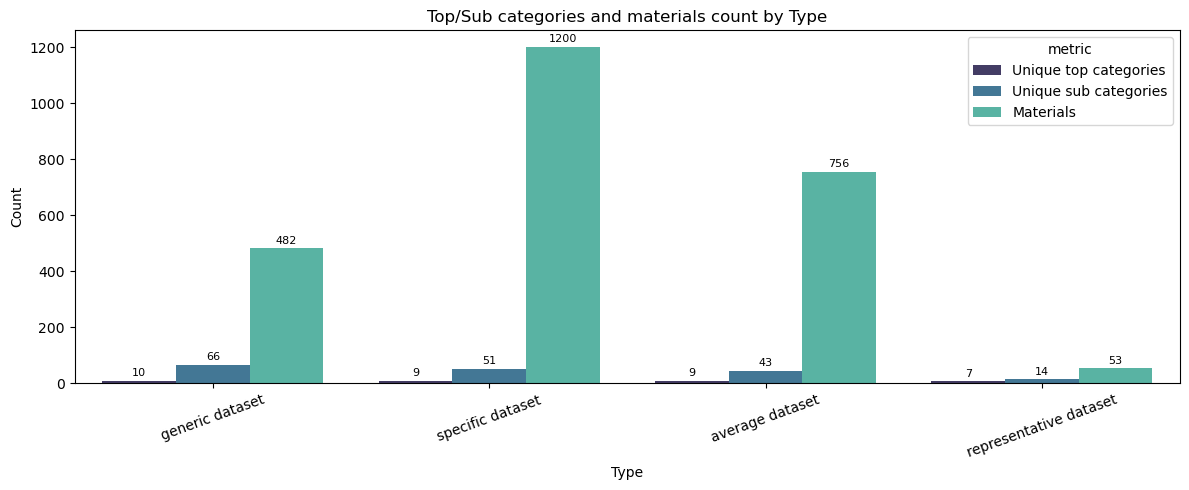

In [122]:
work = df_clean.copy()
work = work.dropna(subset=["Typ", "Top_category", "Sub_category"]).copy()
work["Type"] = work["Typ"].astype(str).str.strip()

type_counts = work["Type"].value_counts()
valid_types = type_counts[type_counts >= 30].index
work = work[work["Type"].isin(valid_types)].copy()

type_stats = (
    work.groupby("Type", as_index=False)
    .agg(
        n_materials=("UUID", "count"),
        n_unique_top_categories=("Top_category", "nunique"),
        n_unique_sub_categories=("Sub_category", "nunique"),   # NEW
        mean_gwp=("GWPtotal (A2)", "mean"),
        mean_fossil=("GWPfossil (A2)", "mean"),
        mean_biogenic=("GWPbiogenic (A2)", "mean"),
    )
    .sort_values("n_unique_sub_categories", ascending=False)
)

plot_stats = type_stats.melt(
    id_vars="Type",
    value_vars=["n_unique_top_categories", "n_unique_sub_categories", "n_materials"],
    var_name="metric",
    value_name="count",
)
plot_stats["metric"] = plot_stats["metric"].map(
    {
        "n_unique_top_categories": "Unique top categories",
        "n_unique_sub_categories": "Unique sub categories",
        "n_materials": "Materials",
    }
)

fig_14, ax_14 = plt.subplots(figsize=(12, 5))
sns.barplot(data=plot_stats, x="Type", y="count", hue="metric", ax=ax_14, palette="mako")
ax_14.set_title("Top/Sub categories and materials count by Type")
ax_14.set_xlabel("Type")
ax_14.set_ylabel("Count")
ax_14.tick_params(axis="x", rotation=20)

for container in ax_14.containers:
    ax_14.bar_label(container, fmt="%.0f", padding=2, fontsize=8)

plt.tight_layout()
type_stats

**Задание 1.5 (адаптация под OBD)**

**Какие категории материалов представлены в каждом типе датасета?**

В столбце `Typ` указан тип датасета материала (`specific dataset`, `generic dataset`, `average dataset`, `representative dataset`). Из столбца `Kategorie (en)` можно извлечь **верхнеуровневую категорию** материала (первый сегмент до разделителя `' / '`).

- Извлеките верхнеуровневую категорию из `Kategorie (en)` в новый столбец `Top_Category`.
- Для каждого типа датасета (`Typ`) постройте `barplot`, в котором будет указана **доля** материалов разных верхнеуровневых категорий (`Top_Category`).
- Полученные значения отсортируйте по убыванию по доле категории `Mineral building products`.

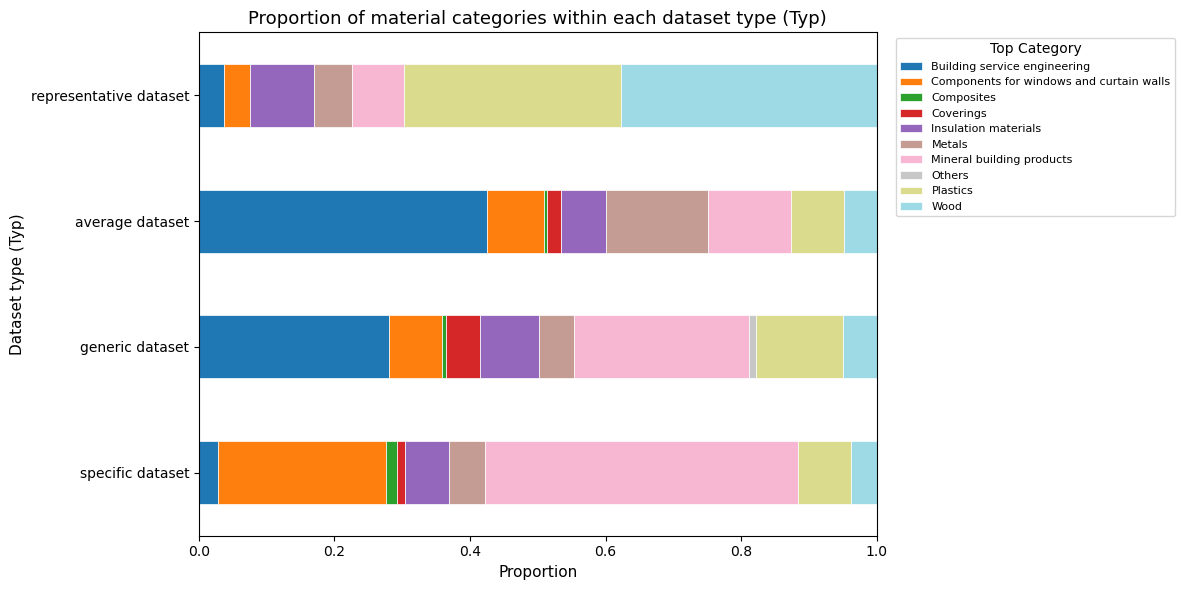

Top_Category,Building service engineering,Components for windows and curtain walls,Composites,Coverings,Insulation materials,Metals,Mineral building products,Others,Plastics,Wood
Typ,,,,,,,,,,
specific dataset,0.027500,0.249167,0.015833,0.010833,0.065833,0.052500,0.462500,0.000000,0.077500,0.038333
generic dataset,0.280083,0.078838,0.006224,0.049793,0.087137,0.051867,0.257261,0.010373,0.128631,0.049793
average dataset,0.424603,0.084656,0.003968,0.021164,0.066138,0.150794,0.121693,0.000000,0.078042,0.048942
representative dataset,0.037736,0.037736,0.000000,0.000000,0.094340,0.056604,0.075472,0.000000,0.320755,0.377358


In [123]:
work_15 = df_clean.copy()

work_15["Top_Category"] = (
    work_15["Kategorie (en)"]
    .str.split("' / '", n=1)
    .str[0]
    .str.strip("' ")
)

ct = pd.crosstab(
    work_15["Typ"],
    work_15["Top_Category"],
    normalize="index", 
)

sort_col = "Mineral building products"
if sort_col in ct.columns:
    ct = ct.sort_values(sort_col, ascending=False)

fig_15, ax_15 = plt.subplots(figsize=(12, 6))
ct.plot(
    kind="barh",
    stacked=True,
    ax=ax_15,
    colormap="tab20",
    edgecolor="white",
    linewidth=0.5,
)

ax_15.set_title(
    "Proportion of material categories within each dataset type (Typ)",
    fontsize=13,
)
ax_15.set_xlabel("Proportion", fontsize=11)
ax_15.set_ylabel("Dataset type (Typ)", fontsize=11)
ax_15.legend(
    title="Top Category",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    fontsize=8,
)
ax_15.set_xlim(0, 1)

plt.tight_layout()
plt.show()

ct

## Задание 2. Работа с выбросами (3 балла)

**Задание 2.1**

В нашем датасете есть несколько признаков, в которых могут находиться выбросы — `GWPtotal (A2)`, `GWPbiogenic (A2)`, `GWPfossil (A2)`, `GWPluluc (A2)`

Используя `boxplot`, идентифицируйте выбросы в переменных в зависимости от типа категории (`Kategory`).

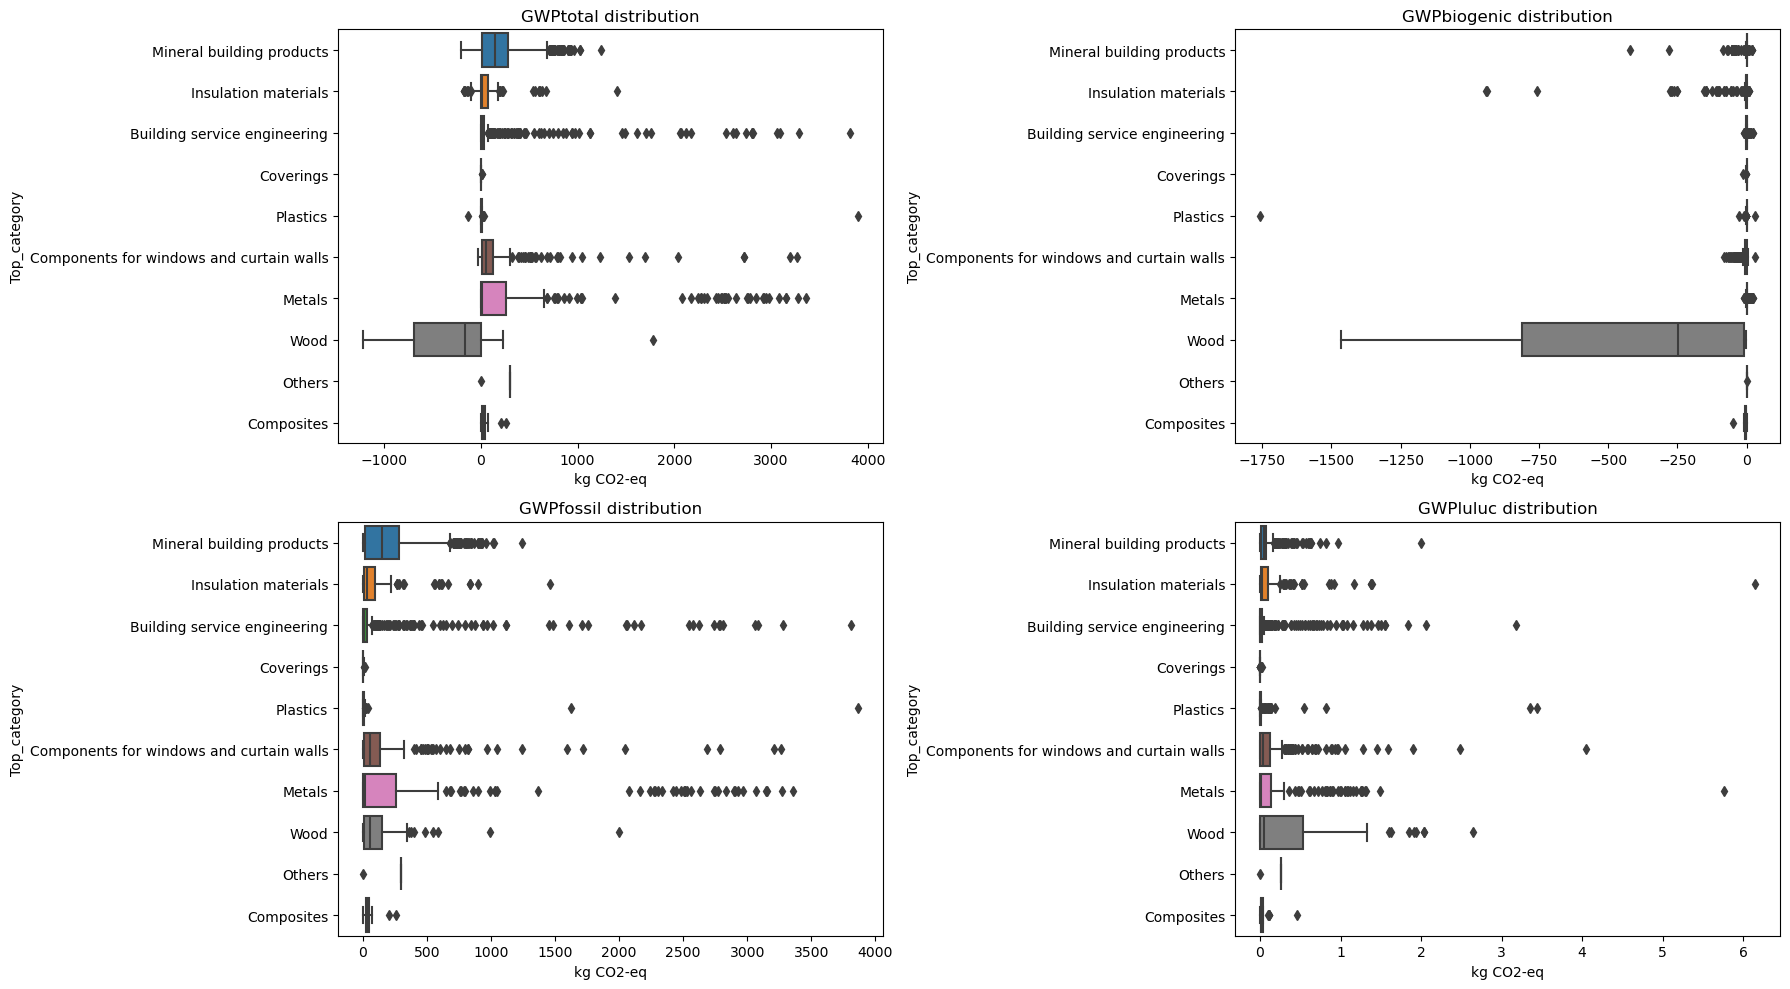

In [124]:
fig, axes = plt.subplots(2, 2, figsize=(18, 10))
axs = axes.ravel()

cat_col = "Top_category"

sns.boxplot(data=box_df, y=cat_col, x="GWPtotal (A2)", ax=axs[0], orient="h")
axs[0].set_title("GWPtotal distribution")
axs[0].set_xlabel("kg CO2-eq")
axs[0].set_ylabel(cat_col)

sns.boxplot(data=box_df, y=cat_col, x="GWPbiogenic (A2)", ax=axs[1], orient="h")
axs[1].set_title("GWPbiogenic distribution")
axs[1].set_xlabel("kg CO2-eq")
axs[1].set_ylabel(cat_col)

sns.boxplot(data=box_df, y=cat_col, x="GWPfossil (A2)", ax=axs[2], orient="h")
axs[2].set_title("GWPfossil distribution")
axs[2].set_xlabel("kg CO2-eq")
axs[2].set_ylabel(cat_col)

sns.boxplot(data=box_df, y=cat_col, x="GWPluluc (A2)", ax=axs[3], orient="h")
axs[3].set_title("GWPluluc distribution")
axs[3].set_xlabel("kg CO2-eq")
axs[3].set_ylabel(cat_col)

plt.tight_layout()
plt.show()

**Задание 2.2**

Посчитайте выбросы в датасете по переменной `GWPtotal (A2)`, которые были обнаружены в задании 2.1.
После подсчета выведите `bar plot`, который будет визуализировать среднний `GWPtotal` в зависимости от типа Категории.

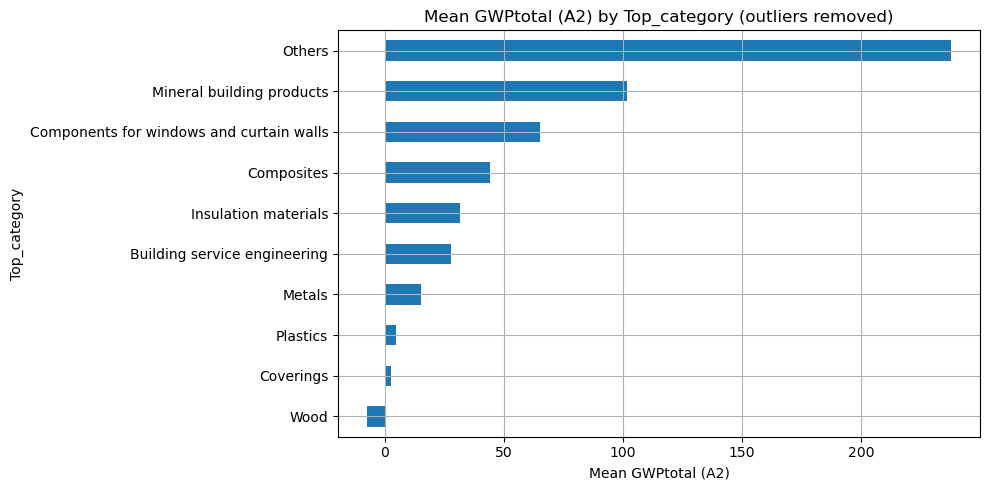

In [125]:
col = "GWPtotal (A2)"

q1, q3 = df_clean[col].quantile([0.25, 0.75])
iqr = q3 - q1
lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr

clean = df_clean[df_clean[col].between(lower, upper)].copy()

mean_gwp = clean.groupby("Top_category")[col].mean().sort_values()

ax = mean_gwp.plot(kind="barh", figsize=(10, 5))
ax.set_title(f"Mean {col} by Top_category (outliers removed)")
ax.set_xlabel(f"Mean {col}")
ax.set_ylabel("Top_category")
ax.grid(True)
plt.tight_layout()
plt.show()

Считаем границы выбросов по правилу IQR (межквартильного размаха):

- `q1, q3 = df_clean[col].quantile([0.25, 0.75])`  
  - `q1` — 25-й перцентиль (первый квартиль): значение, ниже которого находится 25% наблюдений.  
  - `q3` — 75-й перцентиль (третий квартиль): значение, ниже которого находится 75% наблюдений.  
  - То есть центральные 50% данных находятся между `q1` и `q3`.

- `iqr = q3 - q1`  
  - `IQR` (Interquartile Range) — ширина “центрального” диапазона данных.  
  - Чем больше `iqr`, тем сильнее разброс в середине распределения.

- `lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr`  
  - `lower` — нижняя граница нормы.  
  - `upper` — верхняя граница нормы.  
  - Всё, что **меньше `lower`** или **больше `upper`**, считается выбросом.

**Задание 2.3**

С помощью правила трех сигм найдите, какие значения являются экстремальными (выбросами) в столбце `GWPtotal A(2)`. Результат выведите в текстовом виде и сравнить с результатом, полученным с помощью `box plot` в задании 2.1.

In [126]:
col = "GWPtotal (A2)"

mean = df_clean[col].mean()
std = df_clean[col].std()

lower_3s = mean - 3 * std
upper_3s = mean + 3 * std

outliers_3s = df_clean[
    (df_clean[col] < lower_3s) | (df_clean[col] > upper_3s)
]

print(f"Mean = {mean:.2f}")
print(f"Std = {std:.2f}")
print(f"3-sigma bounds: [{lower_3s:.2f}, {upper_3s:.2f}]")
print(f"Outliers (3-sigma): {len(outliers_3s)}")

Mean = 295.72
Std = 2960.56
3-sigma bounds: [-8585.94, 9177.39]
Outliers (3-sigma): 7


**Задание 2.4**

Мы нашли значение, после которого все наши наблюдения можно назвать выбросами.

Создайте `scatter plot (столбцы GWPfossil (A2) и GWPtotal (A2))`, в котором все точки выше верхней границы трёх сигм по GWPtotal (A2) будут помечены красным цветом. Таким образом мы подсветим наши выбросы.

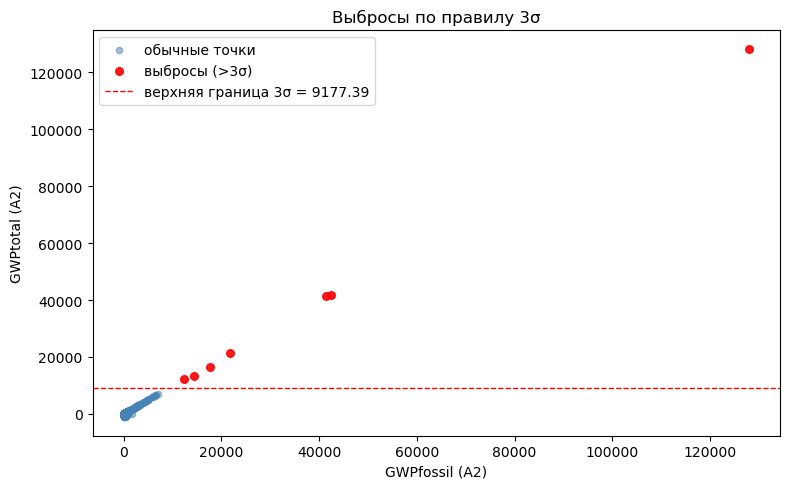

In [127]:
cols = ["GWPfossil (A2)", "GWPtotal (A2)"]
plot_df = df_clean.dropna(subset=cols).copy()

is_outlier = plot_df["GWPtotal (A2)"] > upper_3s

plt.figure(figsize=(8, 5))
plt.scatter(plot_df.loc[~is_outlier, "GWPfossil (A2)"],
            plot_df.loc[~is_outlier, "GWPtotal (A2)"],
            s=20, alpha=0.5, color="steelblue", label="обычные точки")
plt.scatter(plot_df.loc[is_outlier, "GWPfossil (A2)"],
            plot_df.loc[is_outlier, "GWPtotal (A2)"],
            s=30, alpha=0.9, color="red", label="выбросы (>3σ)")
plt.axhline(upper_3s, color="red", ls="--", lw=1, label=f"верхняя граница 3σ = {upper_3s:.2f}")
plt.xlabel("GWPfossil (A2)")
plt.ylabel("GWPtotal (A2)")
plt.title("Выбросы по правилу 3σ")
plt.legend()
plt.tight_layout()
plt.show()

df_clean = df_clean[df_clean["GWPtotal (A2)"] <= upper_3s].copy()

Отлично, теперь можем перейти к построению простой модели.

## Задание 3. Создание простой модели, визуализация результатов работы алгоритма (3 балла)

**Задание 3.1**  
Подготовьте данные для задачи регрессии, где целевая переменная — `GWPtotal (A2)`.  
Сформируйте набор признаков, оставив только те числовые признаки, у которых модуль корреляции с `GWPtotal (A2)` не превышает `0.60`.  
После этого обучите модель `CatBoostRegressor` для предсказания `GWPtotal (A2)` и оцените качество на отложенной выборке (например, с использованием `MAE`, `RMSE`, `R²`).  
Кратко интерпретируйте полученные метрики.

In [128]:
target = "GWPtotal (A2)"

num_df = df_clean.select_dtypes(include="number").copy()
num_df = num_df.dropna(subset=[target])

corr = num_df.corr(numeric_only=True)[target].drop(target).abs().sort_values(ascending=False)

max_corr = 0.60
min_corr = 0.05
selected_features = corr[(corr <= max_corr) & (corr >= min_corr)].index.tolist()

X = num_df[selected_features].copy()
y = num_df[target].copy()

print(f"Выбрано признаков: {len(selected_features)}")
selected_features

Выбрано признаков: 14


['AP (A2)',
 'PERE',
 'Laengengewicht (kg/m)',
 'PENRM',
 'Rohdichte (kg/m3)',
 'PERT',
 'Umrechungsfaktor auf 1kg',
 'GWPbiogenic (A2)',
 'PERM',
 'biogener Kohlenstoffgehalt (Verpackung) in kg',
 'Flaechengewicht (kg/m2)',
 'SOP (A2)',
 'IRP (A2)',
 'Gueltig bis']

| Выбраные признаки                                     | Почему полезен    |
| ------------------------------------------- | ----------------- |
| **Rohdichte (kg/m3)**                       | плотность         |
| **Laengengewicht (kg/m)**                   | масса на метр     |
| **Flaechengewicht (kg/m2)**                 | масса на площадь  |
| **Umrechungsfaktor auf 1kg**                | перевод к массе   |
| **biogener Kohlenstoffgehalt (Verpackung)** | биогенный углерод |


In [133]:
target = "GWPtotal (A2)"
selected_features = [
    "Rohdichte (kg/m3)",
    "Laengengewicht (kg/m)",
    "Flaechengewicht (kg/m2)",
    "Umrechungsfaktor auf 1kg",
    "biogener Kohlenstoffgehalt (Verpackung) in kg",
]

model_df = df_clean.dropna(subset=[target]).copy()

X = model_df[selected_features].copy() 
y = model_df[target].copy()

print(X.shape, y.shape)
print(X.isna().mean().sort_values(ascending=False))

(2484, 5) (2484,)
Laengengewicht (kg/m)                            0.961755
biogener Kohlenstoffgehalt (Verpackung) in kg    0.865137
Umrechungsfaktor auf 1kg                         0.862319
Flaechengewicht (kg/m2)                          0.602657
Rohdichte (kg/m3)                                0.512077
dtype: float64


In [ ]:
# Признаки с большим Nan игнорируем
selected_features = [
    "Rohdichte (kg/m3)",
    "Flaechengewicht (kg/m2)",
]

In [138]:
categorical_features = [
    "Top_categorie",
    "Sub_categorie",
    "Typ",
    "Konformitaet",
    "Laenderkennung",
    "Bezugseinheit"
]

In [141]:
target = "GWPtotal (A2)"

categorical_features = [c for c in categorical_features if c in df_model.columns]

num_features = [c for c in selected_features if c in df_model.columns]
use_cols = num_features + categorical_features + [target]
df_model = df_clean[use_cols].dropna(subset=[target]).copy()

for c in categorical_features:
    df_model[c] = df_model[c].replace({None: np.nan}).fillna("Unknown").astype(str)

In [142]:
X = df_model[num_features + categorical_features]
y = df_model[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

cat_idx = [X.columns.get_loc(c) for c in categorical_features]

model = CatBoostRegressor(
    iterations=1000, 
    learning_rate=0.05, 
    # depth=6,
    loss_function="RMSE", 
    verbose=100, 
    random_state=42
)
model.fit(X_train, y_train, cat_features=cat_idx)

y_pred = model.predict(X_test)
print("MAE :", round(mean_absolute_error(y_test, y_pred), 4))
print("RMSE:", round(mean_squared_error(y_test, y_pred) ** 0.5, 4))
print("R2  :", round(r2_score(y_test, y_pred), 4))

0:	learn: 638.2400909	total: 83.2ms	remaining: 1m 23s
100:	learn: 488.8818753	total: 7.53s	remaining: 1m 7s
200:	learn: 467.4953224	total: 14.6s	remaining: 58.1s
300:	learn: 454.9692635	total: 22.5s	remaining: 52.3s
400:	learn: 445.6064582	total: 30.4s	remaining: 45.4s
500:	learn: 435.4428837	total: 38.2s	remaining: 38.1s
600:	learn: 426.8240671	total: 46.4s	remaining: 30.8s
700:	learn: 415.6798835	total: 54.4s	remaining: 23.2s
800:	learn: 408.5072535	total: 1m 3s	remaining: 15.9s
900:	learn: 400.4676797	total: 1m 12s	remaining: 7.91s
999:	learn: 395.0272349	total: 1m 20s	remaining: 0us
MAE : 158.5172
RMSE: 434.9133
R2  : 0.4126


**Задание 3.2**  
Визуализируйте результаты построенной модели `CatBoostRegressor`:  
1) постройте `scatter plot` «фактические значения `GWPtotal (A2)` vs предсказанные значения модели»;  
2) добавьте на график линию идеального прогноза `y = x`;  
3) сделайте вывод о качестве предсказаний по распределению точек относительно этой линии.  
Дополнительно (по желанию) покажите график важности признаков и прокомментируйте, какие признаки дали наибольший вклад в прогноз.

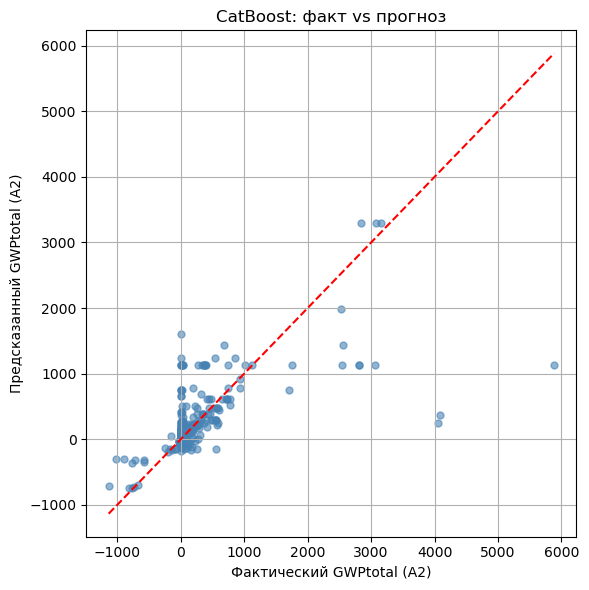

In [147]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, alpha=0.6, s=25, color="steelblue")

lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
plt.plot(lims, lims, "r--", lw=1.5)

plt.xlabel("Фактический GWPtotal (A2)")
plt.ylabel("Предсказанный GWPtotal (A2)")
plt.title("CatBoost: факт vs прогноз")
plt.tight_layout()
plt.grid(True)
plt.show()

In [146]:
feature_importance = model.get_feature_importance()

importance_df = pd.DataFrame({
    "feature": X.columns,
    "importance": feature_importance
}).sort_values("importance", ascending=False)

importance_df

,feature,importance
0,Rohdichte (kg/m3),39.769120
5,Bezugseinheit,19.273705
3,Konformitaet,14.038016
2,Typ,12.429909
4,Laenderkennung,10.060969
1,Flaechengewicht (kg/m2),4.428280


Ура! Анализ завершен. Мы проделали полный цикл работы аналитика от получения датасета до создания простейшей модели. В следующий раз мы познакомимся с более продвинутыми способами использования визуализаций в анализе. Stay tuned :)

## Bonus. Использование карты в качестве визуализаций

Некоторые типы визуализаций работают с конкретными типами данных. Вы могли заметить, что в нашем датасете есть столбцы LATITUDE и LONGITUDE — широта и долгота соответственно. Благодаря этим столбцам мы можем пространственно локализовать наши данные, а значит, создать карту.

К сожалению, в библиотеках `matplotlib` и `seaborn` отсутствует функционал создания карт. Однако создавать карты можно с помощью других библиотек. Одна из наиболее популярных — библиотека `folium`. Именно ей мы и воспользуемся.

Давайте для начала скачаем `folium`.

Теперь можем начинать. В библиотеке `folium` есть отдельный тип данных `folium.map`, который позволяет создавать карту. В ходе создания нужно задать два параметра: `location` — ширина и долгота стартового расположения карты, а также `zoom_start` — стартовое приближение.

Чтобы добавить точки на карту, необходимо воспользоваться следующими функциями:
- `folium.Marker` для создания объекта точки на карте.
- `folium.add_to` для добавления объекта на карту.

Давайте создадим список парных списков, в каждом из которых будет храниться ширина и долгота объекта. Выберем только 500 первых наблюдений в датасете, чтобы не перегружать систему. В качестве описания наших точек (параметр `popup`) будем использовать цену. А направляя курсор на точку, будем отображать адрес (параметр `tooltip`).

Давайте создадим эту карту:


In [148]:
import folium
import pycountry

tmp = df_clean[["Laenderkennung", "GWPtotal (A2)"]].dropna().copy()
tmp["Laenderkennung"] = tmp["Laenderkennung"].astype(str).str.strip().str.upper()

def to_iso3(code):
    if len(code) == 3:
        return code
    if len(code) == 2:
        c = pycountry.countries.get(alpha_2=code)
        return c.alpha_3 if c else None
    return None

tmp["iso3"] = tmp["Laenderkennung"].apply(to_iso3)
country_gwp = (
    tmp.dropna(subset=["iso3"])
       .groupby("iso3", as_index=False)["GWPtotal (A2)"]
       .mean()
       .rename(columns={"GWPtotal (A2)": "gwp_mean"})
)


m = folium.Map(location=[20, 0], zoom_start=2, tiles="cartodbpositron")

world_geojson = "https://raw.githubusercontent.com/python-visualization/folium/master/examples/data/world-countries.json"

folium.Choropleth(
    geo_data=world_geojson,
    data=country_gwp,
    columns=["iso3", "gwp_mean"],
    key_on="feature.id",          # world-countries.json uses ISO3 in feature.id
    fill_color="YlOrRd",
    fill_opacity=0.7,
    line_opacity=0.2,
    legend_name="Mean GWPtotal (A2)"
).add_to(m)

m

Отлично!

Мы видим, что карта успешно создалась. Используя полученную визуализацию, мы уже можем сделать несколько выводов:
- После кликов на разные варианты оказалось, что средняя цена в Манхэттене сильно выше, чем в Бронксе (кто бы мог подумать!)
- Данные, которые у нас есть, относятся только к городу Нью-Йорку, а не к штату. Поскольку все перечисленные точки относятся к одному из пять боро города Нью-Йорк.
- Апартаменты, продающиеся в городе, распределены равномерно: судя по всему, спросом пользуются квартиры всех районов города.

Таким образом, просто создав карту недвижимости, мы можем получить большое количество информации о нашем датасете. Это может помочь вам в дальнейшей работе. Удачи!